# Notebook 05. Đánh giá Chỉ số Digital Burnout (DBI)

Notebook này thực hiện xây dựng bộ dữ liệu đánh giá **Digital Burnout Indicator (DBI)** trên dữ liệu khảo sát sinh viên Việt Nam.

Quy trình bao gồm:

1. Tải dữ liệu khảo sát đã được tiền xử lý.
2. Tải danh sách đặc trưng đã được xác thực.
3. Tải bảng ánh xạ giữa đặc trưng và Candidate Indicators.
4. Chuẩn hóa các chỉ số thành phần.
5. Tính điểm cho từng nhóm chỉ số DBI.
6. Xuất bộ dữ liệu phục vụ xây dựng DBI Framework.

Lưu ý: Notebook này **chỉ tính điểm cho từng nhóm chỉ số (DBI Dimensions)**, chưa tính điểm DBI tổng hợp. Trọng số của từng nhóm chỉ số sẽ được xác định trong giai đoạn xây dựng **DBI Framework**.

# 0. Set Up

Thiết lập môi trường thực thi cho Notebook 04 - Feature Validation.

In [60]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

print("Đã import thư viện.")

Đã import thư viện.


In [61]:
# Thiết lập đường dẫn dữ liệu

survey_path = Path(
    "../../data/processed/vietnam_dataset/vn_digital_burnout_cleaned.csv"
)

validated_feature_path = Path(
    "../../data/processed/vietnam_dataset/validated_features.csv"
)

mapping_path = Path(
    "../../data/processed/vietnam_dataset/feature_indicator_mapping.csv"
)

output_path = Path(
    "../../data/processed/vietnam_dataset/student_dbi_dimension_scores.csv"
)

print("Đã thiết lập đường dẫn dữ liệu.")

Đã thiết lập đường dẫn dữ liệu.


# 1. Tải dữ liệu

Phần này thực hiện tải toàn bộ dữ liệu cần thiết cho quá trình xây dựng chỉ số Digital Burnout.

Bao gồm:

- Bộ dữ liệu khảo sát đã làm sạch.
- Danh sách các đặc trưng đã được xác thực.
- Bảng ánh xạ giữa đặc trưng và Candidate Indicators.

Các dữ liệu này sẽ được sử dụng để tính toán điểm cho từng nhóm chỉ số DBI ở các phần tiếp theo.

In [62]:
# Đọc dữ liệu khảo sát

df = pd.read_csv(survey_path)

print("Kích thước dữ liệu:")

display(df.shape)

display(df.head())

Kích thước dữ liệu:


(590, 23)

,gender,birth_year,education_stage,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue
0,Nam,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",2,2,4,3,0,1,1,1,3,2,0,3,1,1,10,1,1,4
1,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Cân bằng cả học lẫn giải trí,3,1,1,1,1,1,2,6,1,1,1,3,3,9,9,5,5,4
2,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",4,2,2,3,3,2,3,7,1,3,2,2,3,8,6,5,5,5
3,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Tự do, không cố định lịch trình",Cân bằng cả học lẫn giải trí,3,2,1,3,1,1,1,6,1,3,1,3,1,4,8,4,5,3
4,Nữ,2009 - 2012,Học sinh THPT,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",4,3,4,3,2,1,1,7,1,2,1,0,3,8,4,2,2,4


In [63]:
# Đọc danh sách Validated Features

validated_features = pd.read_csv(
    validated_feature_path
)

display(validated_features)

,feature,selected
0,late_night_device_usage,True
1,stress_level,True
2,doomscrolling_duration,True
3,daily_screen_time,True
4,mental_fatigue,True
5,emotional_exhaustion,True
6,notification_count,True
7,app_switch_frequency,True
8,social_media_hours,True
9,concentration_score,True


In [64]:
# Đọc bảng Feature - Indicator Mapping

mapping_table = pd.read_csv(
    mapping_path
)

display(mapping_table.head())

,feature,indicator_id,indicator_name,dbi_dimension,mapping_type
0,daily_screen_time,DE01,Daily Total Screen Time,Digital Exposure,Direct
1,social_media_hours,DE02,Media Multitasking Frequency,Digital Exposure,Proxy
2,app_switch_frequency,DE02,Media Multitasking Frequency,Digital Exposure,Direct
3,notification_count,DE04,Notification Check Frequency,Digital Exposure,Direct
4,smartphone_unlocks,DE04,Notification Check Frequency,Digital Exposure,Proxy


In [65]:
# Danh sách Feature sử dụng

selected_features = validated_features[
    "feature"
].tolist()

print(f"Số lượng Feature: {len(selected_features)}")

selected_features

Số lượng Feature: 18


['late_night_device_usage',
 'stress_level',
 'doomscrolling_duration',
 'daily_screen_time',
 'mental_fatigue',
 'emotional_exhaustion',
 'notification_count',
 'app_switch_frequency',
 'social_media_hours',
 'concentration_score',
 'distraction_frequency',
 'focus_sessions',
 'sleep_quality',
 'task_completion_rate',
 'sleep_hours',
 'motivation_level',
 'smartphone_unlocks',
 'deep_work_hours']

In [66]:
# Đọc Digital Burnout Indicator Framework

dbi_framework_path = (
    "../../data/processed/cross_dataset_analysis/"
    "dbi_framework.csv"
)

dbi_framework = pd.read_csv(dbi_framework_path)

print("Đã tải Digital Burnout Indicator Framework thành công.")
print(f"Số lượng chỉ số: {dbi_framework.shape[0]}")

Đã tải Digital Burnout Indicator Framework thành công.
Số lượng chỉ số: 12


# 2. Xây dựng chỉ số DBI

Phần này thực hiện chuẩn hóa các đặc trưng đã được xác thực và xây dựng điểm cho từng nhóm chỉ số Digital Burnout.

Để đảm bảo các đặc trưng có cùng thang đo, toàn bộ biến sẽ được chuẩn hóa về khoảng giá trị từ 0 đến 1 bằng phương pháp Min-Max Scaling.

Đối với các đặc trưng có tác động bảo vệ (giá trị càng cao thì nguy cơ Digital Burnout càng thấp), giá trị sẽ được đảo chiều trước khi tính điểm nhằm thống nhất hướng tác động của tất cả các chỉ số.

## 2.1 Chuẩn hóa các đặc trưng

Chuẩn hóa các đặc trưng đã được xác thực về cùng một thang đo từ 0 đến 1 bằng phương pháp Min-Max Scaling.

Việc chuẩn hóa giúp đảm bảo các chỉ số có đơn vị đo khác nhau vẫn có thể được tổng hợp để tính điểm DBI.

In [67]:
# Sao chép dữ liệu để chuẩn hóa

dbi_data = df.copy()

# Danh sách đặc trưng sử dụng

selected_features = validated_features["feature"].tolist()

# Khởi tạo Min-Max Scaler

scaler = MinMaxScaler()

# Chuẩn hóa dữ liệu

dbi_data[selected_features] = scaler.fit_transform(
    dbi_data[selected_features]
)

print("Đã chuẩn hóa các đặc trưng.")

display(
    dbi_data[selected_features].head()
)

Đã chuẩn hóa các đặc trưng.


,late_night_device_usage,stress_level,doomscrolling_duration,daily_screen_time,mental_fatigue,emotional_exhaustion,notification_count,app_switch_frequency,social_media_hours,concentration_score,distraction_frequency,focus_sessions,sleep_quality,task_completion_rate,sleep_hours,motivation_level,smartphone_unlocks,deep_work_hours
0,1.000000,0.00,1.00,0.50,0.75,0.00,0.000000,0.333333,0.666667,0.000000,1.000000,0.666667,0.000000,1.000000,0.25,1.000000,0.333333,0.000000
1,0.333333,1.00,0.25,0.75,0.75,1.00,0.333333,0.666667,0.333333,0.555556,0.333333,0.333333,0.888889,1.000000,0.75,0.888889,0.333333,0.333333
2,1.000000,1.00,0.50,1.00,1.00,1.00,1.000000,1.000000,0.666667,0.666667,0.333333,1.000000,0.777778,0.666667,0.75,0.555556,0.666667,0.666667
3,1.000000,1.00,0.25,0.75,0.50,0.75,0.333333,0.333333,0.666667,0.555556,0.333333,1.000000,0.333333,1.000000,0.25,0.777778,0.333333,0.333333
4,1.000000,0.25,1.00,1.00,0.75,0.25,0.666667,0.333333,1.000000,0.666667,0.333333,0.666667,0.777778,0.000000,0.75,0.333333,0.333333,0.333333


## 2.2 Đảo chiều các chỉ số bảo vệ

Một số đặc trưng phản ánh yếu tố bảo vệ đối với Digital Burnout.

Đối với các đặc trưng này, giá trị càng cao đồng nghĩa với nguy cơ Digital Burnout càng thấp.

Do đó, các chỉ số sẽ được đảo chiều để đảm bảo tất cả các đặc trưng đều có cùng hướng tác động, trong đó giá trị càng cao thể hiện nguy cơ Digital Burnout càng lớn.

In [68]:
# Khai báo các đặc trưng cần đảo chiều

protective_features = [

    "concentration_score",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "sleep_hours",
    "sleep_quality"

]

print("Các đặc trưng cần đảo chiều:")

display(protective_features)

Các đặc trưng cần đảo chiều:


['concentration_score',
 'focus_sessions',
 'deep_work_hours',
 'task_completion_rate',
 'sleep_hours',
 'sleep_quality']

In [69]:
# Đảo chiều các đặc trưng bảo vệ

dbi_data[protective_features] = (
    1 - dbi_data[protective_features]
)

print("Đã đảo chiều các đặc trưng bảo vệ.")

display(
    dbi_data[
        protective_features
    ].head()
)

Đã đảo chiều các đặc trưng bảo vệ.


,concentration_score,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality
0,1.000000,0.333333,1.000000,0.000000,0.75,1.000000
1,0.444444,0.666667,0.666667,0.000000,0.25,0.111111
2,0.333333,0.000000,0.333333,0.333333,0.25,0.222222
3,0.444444,0.000000,0.666667,0.000000,0.75,0.666667
4,0.333333,0.333333,0.666667,1.000000,0.25,0.222222


# 3. Tính điểm các chỉ số Digital Burnout (DBI)

Chuyển đổi các đặc trưng khảo sát đã được chuẩn hóa thành các chỉ số Digital Burnout theo Digital Burnout Indicator Framework. Quá trình này bao gồm việc ánh xạ đặc trưng với từng Indicator, tính điểm Indicator, áp dụng trọng số và tổng hợp thành điểm của từng Dimension cũng như điểm Digital Burnout tổng thể.

Các Indicator được tính toán dựa trên các đặc trưng đã được chuẩn hóa trong bộ dữ liệu khảo sát. Sau đó, trọng số của từng Indicator được lấy từ Digital Burnout Indicator Framework để tính điểm cho từng Dimension và điểm DBI tổng hợp.

## 3.1 Xây dựng điểm từng Indicator

Xây dựng điểm số cho từng Digital Burnout Indicator dựa trên mối quan hệ giữa đặc trưng khảo sát và Indicator được xác định trong Digital Burnout Indicator Framework.

Mỗi Indicator được đại diện bởi một hoặc nhiều đặc trưng khảo sát. Các đặc trưng này được tổng hợp để tạo thành điểm Indicator tương ứng.

Việc tính toán được thực hiện dựa trên bảng ánh xạ Feature → Indicator (`mapping_table`). Những Indicator có nhiều đặc trưng thành phần sẽ sử dụng giá trị trung bình của các đặc trưng đó nhằm tạo ra điểm đại diện.

In [70]:
# Kiểm tra bảng ánh xạ Feature và Indicator

mapping_table.head()

,feature,indicator_id,indicator_name,dbi_dimension,mapping_type
0,daily_screen_time,DE01,Daily Total Screen Time,Digital Exposure,Direct
1,social_media_hours,DE02,Media Multitasking Frequency,Digital Exposure,Proxy
2,app_switch_frequency,DE02,Media Multitasking Frequency,Digital Exposure,Direct
3,notification_count,DE04,Notification Check Frequency,Digital Exposure,Direct
4,smartphone_unlocks,DE04,Notification Check Frequency,Digital Exposure,Proxy


In [71]:
# Khởi tạo bảng lưu điểm Indicator

indicator_scores = pd.DataFrame(
    index=dbi_data.index
)


# Tính điểm từng Indicator dựa trên các feature được ánh xạ

for indicator_id in mapping_table["indicator_id"].unique():

    mapped_features = (
        mapping_table[
            mapping_table["indicator_id"] == indicator_id
        ]["feature"]
        .tolist()
    )


    indicator_scores[indicator_id] = (
        dbi_data[mapped_features]
        .mean(axis=1)
    )


print("Đã tính điểm cho các Indicator.")

Đã tính điểm cho các Indicator.


In [72]:
# Kiểm tra kết quả điểm Indicator đã được xây dựng

indicator_scores.head()

,DE01,DE02,DE04,DE05,PS02,CP03,CP02,CP04,SR01,SR05,PS03,PS04
0,0.50,0.500000,0.166667,1.000000,1.00,0.777778,1.000000,0.000000,0.75,1.000000,0.000,0.75
1,0.75,0.500000,0.333333,0.333333,0.25,0.481481,0.666667,0.000000,0.25,0.111111,1.000,0.75
2,1.00,0.833333,0.833333,1.000000,0.50,0.222222,0.333333,0.333333,0.25,0.222222,1.000,1.00
3,0.75,0.500000,0.333333,1.000000,0.25,0.259259,0.666667,0.000000,0.75,0.666667,0.875,0.50
4,1.00,0.666667,0.500000,1.000000,1.00,0.333333,0.666667,1.000000,0.25,0.222222,0.250,0.75


## 3.2 Áp dụng trọng số Indicator

Điều chỉnh mức độ đóng góp của từng Indicator trong quá trình đánh giá Digital Burnout dựa trên trọng số được xác định trong Digital Burnout Indicator Framework.

Mỗi Indicator có mức độ ảnh hưởng khác nhau đến nguy cơ Digital Burnout. Do đó, điểm Indicator sau khi được tính toán sẽ được nhân với trọng số tương ứng trong Framework.

Công thức:

Weighted Indicator Score = Indicator Score × Indicator Weight

Trong đó:

- `Indicator Score` là điểm của từng Indicator được tính từ dữ liệu khảo sát.
- `Indicator Weight` là trọng số được xác định trong DBI Framework.

In [73]:
# Lấy trọng số của từng Indicator từ DBI Framework

indicator_weights = (
    dbi_framework[
        [
            "indicator_id",
            "indicator_weight"
        ]
    ]
    .set_index("indicator_id")
)


indicator_weights.head()

,indicator_weight
indicator_id,
PS03,0.211084
DE01,0.132131
PS02,0.126747
CP03,0.088117
DE05,0.096944


In [77]:
# Áp dụng trọng số cho từng Indicator Score

weighted_indicator_scores = indicator_scores.copy()


for indicator_id in weighted_indicator_scores.columns:

    weight = indicator_weights.loc[
        indicator_id,
        "indicator_weight"
    ]


    weighted_indicator_scores[indicator_id] = (
        weighted_indicator_scores[indicator_id]
        * weight
    )


print("Đã áp dụng trọng số cho các Indicator.")

Đã áp dụng trọng số cho các Indicator.


In [78]:
display(
    weighted_indicator_scores.head()
)

,DE01,DE02,DE04,DE05,PS02,CP03,CP02,CP04,SR01,SR05,PS03,PS04
0,0.066066,0.016158,0.011115,0.096944,0.126747,0.068535,0.067210,0.000000,0.063749,0.030888,0.000000,0.023052
1,0.099099,0.016158,0.022229,0.032315,0.031687,0.042427,0.044807,0.000000,0.021250,0.003432,0.211084,0.023052
2,0.132131,0.026930,0.055573,0.096944,0.063373,0.019581,0.022403,0.010714,0.021250,0.006864,0.211084,0.030736
3,0.099099,0.016158,0.022229,0.096944,0.031687,0.022845,0.044807,0.000000,0.063749,0.020592,0.184698,0.015368
4,0.132131,0.021544,0.033344,0.096944,0.126747,0.029372,0.044807,0.032141,0.021250,0.006864,0.052771,0.023052


## 3.3 Tính điểm từng nhóm chỉ số DBI

Tổng hợp các Indicator thành điểm số của từng nhóm Dimension trong Digital Burnout Framework.

Các Indicator được phân nhóm theo bốn Dimension chính:

- Digital Exposure
- Sleep & Recovery
- Cognitive Performance
- Psychological Symptoms

Điểm của mỗi Dimension được tính bằng tổng các Indicator thành phần sau khi đã áp dụng trọng số.

In [79]:
# Tạo bảng ánh xạ Indicator với Dimension

indicator_dimension_mapping = (
    dbi_framework[
        [
            "indicator_id",
            "dbi_dimension"
        ]
    ]
)


display(
    indicator_dimension_mapping.head()
)

,indicator_id,dbi_dimension
0,PS03,Psychological Symptoms
1,DE01,Digital Exposure
2,PS02,Psychological Symptoms
3,CP03,Cognitive Performance
4,DE05,Digital Exposure


In [80]:
# Khởi tạo bảng điểm Dimension

dimension_scores = pd.DataFrame(
    index=weighted_indicator_scores.index
)


# Tính tổng điểm theo từng Dimension

for dimension in indicator_dimension_mapping["dbi_dimension"].unique():

    indicator_list = (
        indicator_dimension_mapping[
            indicator_dimension_mapping["dbi_dimension"] == dimension
        ]["indicator_id"]
        .tolist()
    )


    dimension_scores[dimension] = (
        weighted_indicator_scores[indicator_list]
        .sum(axis=1)
    )


print("Đã tính điểm cho các nhóm Dimension DBI.")

Đã tính điểm cho các nhóm Dimension DBI.


In [81]:
# Hiển thị điểm các Dimension

display(
    dimension_scores.head()
)

,Psychological Symptoms,Digital Exposure,Cognitive Performance,Sleep & Recovery
0,0.149799,0.190282,0.135745,0.094637
1,0.265822,0.169800,0.087233,0.024682
2,0.305193,0.311578,0.052699,0.028114
3,0.231753,0.234430,0.067652,0.084341
4,0.202570,0.283963,0.106320,0.028114


In [82]:
# Chuẩn hóa tên cột Dimension

dimension_scores.columns = [
    col.lower()
        .replace(" ", "_")
        .replace("&", "and")
    + "_score"
    for col in dimension_scores.columns
]


display(
    dimension_scores.head()
)

,psychological_symptoms_score,digital_exposure_score,cognitive_performance_score,sleep_and_recovery_score
0,0.149799,0.190282,0.135745,0.094637
1,0.265822,0.169800,0.087233,0.024682
2,0.305193,0.311578,0.052699,0.028114
3,0.231753,0.234430,0.067652,0.084341
4,0.202570,0.283963,0.106320,0.028114


## 3.4 Tổng hợp điểm Digital Burnout Index

Tính toán điểm Digital Burnout Index (DBI) tổng thể cho từng cá nhân dựa trên điểm của các Dimension.

Điểm DBI tổng thể được xác định bằng tổng điểm của bốn Dimension sau khi đã được chuẩn hóa theo trọng số Framework:

- Digital Exposure
- Psychological Symptoms
- Cognitive Performance
- Sleep & Recovery

Điểm DBI càng cao thể hiện mức độ nguy cơ Digital Burnout càng lớn.

In [83]:
# Tính điểm DBI tổng thể từ các Dimension Score

dbi_data = dimension_scores.copy()


dbi_data["digital_burnout_score"] = (
    dbi_data[
        [
            "psychological_symptoms_score",
            "digital_exposure_score",
            "cognitive_performance_score",
            "sleep_and_recovery_score"
        ]
    ]
    .sum(axis=1)
)


print("Đã tính điểm Digital Burnout Index.")

Đã tính điểm Digital Burnout Index.


In [84]:
# Hiển thị điểm DBI tổng thể

display(
    dbi_data[
        [
            "digital_burnout_score"
        ]
    ]
    .head()
)

,digital_burnout_score
0,0.570464
1,0.547538
2,0.697583
3,0.618176
4,0.620966


Do chưa tồn tại ngưỡng chuẩn hóa quốc tế cho Digital Burnout Index, nghiên cứu sử dụng phương pháp phân vị để phân nhóm mức độ rủi ro dựa trên phân bố của dữ liệu khảo sát.

Quy tắc phân loại:

- Low Risk: nhóm 33% điểm thấp nhất.
- Medium Risk: nhóm 33% ở giữa.
- High Risk: nhóm 33% điểm cao nhất.

In [85]:
# Xác định ngưỡng phân loại DBI

low_threshold = (
    dbi_data["digital_burnout_score"]
    .quantile(0.33)
)


high_threshold = (
    dbi_data["digital_burnout_score"]
    .quantile(0.66)
)


# Phân loại mức độ Digital Burnout

def classify_dbi(score):

    if score <= low_threshold:
        return "Low Risk"

    elif score <= high_threshold:
        return "Medium Risk"

    else:
        return "High Risk"



dbi_data["dbi_level"] = (
    dbi_data["digital_burnout_score"]
    .apply(classify_dbi)
)


print("Đã phân loại mức độ Digital Burnout.")

Đã phân loại mức độ Digital Burnout.


In [86]:
# Kiểm tra kết quả phân loại

display(
    dbi_data[
        [
            "digital_burnout_score",
            "dbi_level"
        ]
    ]
    .head()
)

,digital_burnout_score,dbi_level
0,0.570464,Low Risk
1,0.547538,Low Risk
2,0.697583,Medium Risk
3,0.618176,Medium Risk
4,0.620966,Medium Risk


# 4. Tổng hợp kết quả đánh giá DBI

Phần này tổng hợp và kiểm tra kết quả sau khi hoàn thành quá trình chuẩn hóa các đặc trưng và tính điểm cho từng nhóm chỉ số Digital Burnout.

Các thống kê mô tả và bộ dữ liệu đánh giá DBI được trình bày nhằm đánh giá tính hợp lý của các điểm số trước khi sử dụng trong giai đoạn xây dựng **Digital Burnout Indicator (DBI) Framework** và phân tích so sánh giữa bộ dữ liệu quốc tế và dữ liệu khảo sát sinh viên Việt Nam.

## 4.1 Phân bố điểm các nhóm chỉ số DBI

Phần này trình bày thống kê mô tả của bốn nhóm chỉ số Digital Burnout nhằm đánh giá phân bố điểm trong bộ dữ liệu khảo sát.

Các kết quả này giúp kiểm tra tính hợp lý của quá trình chuẩn hóa và tính điểm trước khi xây dựng DBI Framework.## 4.1 Phân bố điểm các nhóm chỉ số DBI

Phân tích sự phân bố của điểm DBI tổng thể và các Dimension nhằm đánh giá mức độ khác biệt về hành vi sử dụng công nghệ, khả năng nhận thức, phục hồi và triệu chứng tâm lý trong dữ liệu khảo sát.

Các chỉ số được trực quan hóa bao gồm:

- Digital Burnout Score
- Psychological Symptoms Score
- Digital Exposure Score
- Cognitive Performance Score
- Sleep and Recovery Score

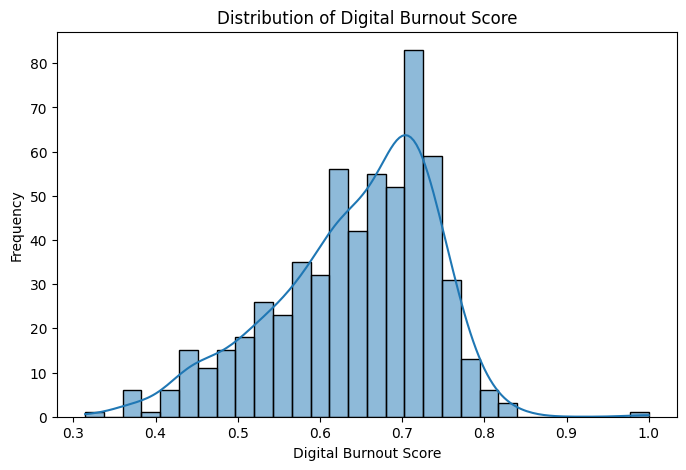

In [87]:
# Trực quan hóa phân bố điểm Digital Burnout Index

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))


sns.histplot(
    data=dbi_data,
    x="digital_burnout_score",
    bins=30,
    kde=True
)


plt.title("Distribution of Digital Burnout Score")
plt.xlabel("Digital Burnout Score")
plt.ylabel("Frequency")


plt.show()

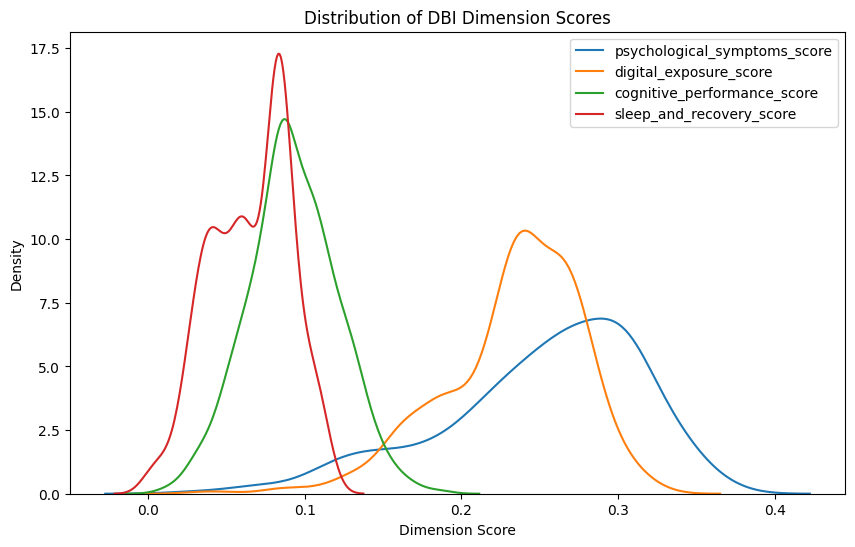

In [88]:
# Trực quan hóa phân bố điểm các Dimension

dimension_columns = [
    "psychological_symptoms_score",
    "digital_exposure_score",
    "cognitive_performance_score",
    "sleep_and_recovery_score"
]


plt.figure(figsize=(10, 6))


for column in dimension_columns:

    sns.kdeplot(
        data=dbi_data,
        x=column,
        label=column
    )


plt.title("Distribution of DBI Dimension Scores")
plt.xlabel("Dimension Score")
plt.ylabel("Density")

plt.legend()

plt.show()

In [89]:
# Tính thống kê mô tả cho các điểm DBI

dbi_summary = (
    dbi_data[
        dimension_columns
        +
        [
            "digital_burnout_score"
        ]
    ]
    .describe()
)


display(dbi_summary)

,psychological_symptoms_score,digital_exposure_score,cognitive_performance_score,sleep_and_recovery_score,digital_burnout_score
count,590.000000,590.000000,590.000000,590.000000,590.000000
mean,0.251331,0.232755,0.092473,0.065597,0.642156
std,0.064240,0.044250,0.028520,0.025645,0.096381
min,0.026385,0.033033,0.009791,0.000000,0.314298
25%,0.218353,0.208273,0.074581,0.045274,0.583906
50%,0.263440,0.239816,0.090444,0.067181,0.662473
75%,0.302810,0.267431,0.110537,0.084341,0.709544
max,0.368566,0.328079,0.187468,0.115887,1.000000


## 4.2 Bộ dữ liệu đánh giá DBI

Xây dựng bộ dữ liệu cuối cùng chứa toàn bộ thông tin về đặc điểm hành vi sử dụng thiết bị, điểm số các Indicator, Dimension Score và kết quả đánh giá Digital Burnout Index.

Bộ dữ liệu đánh giá DBI được tạo bằng cách kết hợp:

- Dữ liệu khảo sát sinh viên Việt Nam ban đầu.
- Điểm số các Indicator trong DBI Framework.
- Điểm số của từng Dimension.
- Điểm Digital Burnout Index tổng thể.
- Nhóm mức độ rủi ro Digital Burnout.

Bộ dữ liệu này sẽ được sử dụng cho:

- Phân tích đặc điểm Digital Burnout của sinh viên Việt Nam.
- Xây dựng Dashboard đánh giá DBI.
- So sánh với bộ dữ liệu quốc tế trong bước Cross-Dataset Analysis.

In [90]:
# Sao chép điểm Indicator để ghép vào bộ dữ liệu đánh giá

indicator_score_dataset = indicator_scores.copy()


indicator_score_dataset.columns = [
    f"{column}_indicator_score"
    for column in indicator_score_dataset.columns
]


indicator_score_dataset.head()

,DE01_indicator_score,DE02_indicator_score,DE04_indicator_score,DE05_indicator_score,PS02_indicator_score,CP03_indicator_score,CP02_indicator_score,CP04_indicator_score,SR01_indicator_score,SR05_indicator_score,PS03_indicator_score,PS04_indicator_score
0,0.50,0.500000,0.166667,1.000000,1.00,0.777778,1.000000,0.000000,0.75,1.000000,0.000,0.75
1,0.75,0.500000,0.333333,0.333333,0.25,0.481481,0.666667,0.000000,0.25,0.111111,1.000,0.75
2,1.00,0.833333,0.833333,1.000000,0.50,0.222222,0.333333,0.333333,0.25,0.222222,1.000,1.00
3,0.75,0.500000,0.333333,1.000000,0.25,0.259259,0.666667,0.000000,0.75,0.666667,0.875,0.50
4,1.00,0.666667,0.500000,1.000000,1.00,0.333333,0.666667,1.000000,0.25,0.222222,0.250,0.75


In [91]:
# Ghép dữ liệu khảo sát với các kết quả đánh giá DBI

vietnam_dbi_assessment_dataset = pd.concat(
    [
        df.reset_index(drop=True),
        indicator_score_dataset.reset_index(drop=True),
        dimension_scores.reset_index(drop=True),
        dbi_data[
            [
                "digital_burnout_score",
                "dbi_level"
            ]
        ]
        .reset_index(drop=True)
    ],
    axis=1
)


print("Đã xây dựng bộ dữ liệu đánh giá DBI.")

Đã xây dựng bộ dữ liệu đánh giá DBI.


In [92]:
# Kiểm tra kích thước bộ dữ liệu đánh giá DBI

print(
    f"Số lượng quan sát: {vietnam_dbi_assessment_dataset.shape[0]:,}"
)

print(
    f"Số lượng đặc trưng: {vietnam_dbi_assessment_dataset.shape[1]:,}"
)

Số lượng quan sát: 590
Số lượng đặc trưng: 41


In [93]:
# Hiển thị một số dòng đầu tiên của bộ dữ liệu

display(
    vietnam_dbi_assessment_dataset.head()
)

,gender,birth_year,education_stage,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue,DE01_indicator_score,DE02_indicator_score,DE04_indicator_score,DE05_indicator_score,PS02_indicator_score,CP03_indicator_score,CP02_indicator_score,CP04_indicator_score,SR01_indicator_score,SR05_indicator_score,PS03_indicator_score,PS04_indicator_score,psychological_symptoms_score,digital_exposure_score,cognitive_performance_score,sleep_and_recovery_score,digital_burnout_score,dbi_level
0,Nam,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",2,2,4,3,0,1,1,1,3,2,0,3,1,1,10,1,1,4,0.50,0.500000,0.166667,1.000000,1.00,0.777778,1.000000,0.000000,0.75,1.000000,0.000,0.75,0.149799,0.190282,0.135745,0.094637,0.570464,Low Risk
1,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Cân bằng cả học lẫn giải trí,3,1,1,1,1,1,2,6,1,1,1,3,3,9,9,5,5,4,0.75,0.500000,0.333333,0.333333,0.25,0.481481,0.666667,0.000000,0.25,0.111111,1.000,0.75,0.265822,0.169800,0.087233,0.024682,0.547538,Low Risk
2,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",4,2,2,3,3,2,3,7,1,3,2,2,3,8,6,5,5,5,1.00,0.833333,0.833333,1.000000,0.50,0.222222,0.333333,0.333333,0.25,0.222222,1.000,1.00,0.305193,0.311578,0.052699,0.028114,0.697583,Medium Risk
3,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Tự do, không cố định lịch trình",Cân bằng cả học lẫn giải trí,3,2,1,3,1,1,1,6,1,3,1,3,1,4,8,4,5,3,0.75,0.500000,0.333333,1.000000,0.25,0.259259,0.666667,0.000000,0.75,0.666667,0.875,0.50,0.231753,0.234430,0.067652,0.084341,0.618176,Medium Risk
4,Nữ,2009 - 2012,Học sinh THPT,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",4,3,4,3,2,1,1,7,1,2,1,0,3,8,4,2,2,4,1.00,0.666667,0.500000,1.000000,1.00,0.333333,0.666667,1.000000,0.25,0.222222,0.250,0.75,0.202570,0.283963,0.106320,0.028114,0.620966,Medium Risk


In [94]:
# Thống kê số lượng sinh viên theo nhóm DBI

dbi_level_distribution = (
    vietnam_dbi_assessment_dataset[
        "dbi_level"
    ]
    .value_counts()
    .reset_index()
)


dbi_level_distribution.columns = [
    "dbi_level",
    "student_count"
]


display(
    dbi_level_distribution
)

,dbi_level,student_count
0,High Risk,201
1,Low Risk,195
2,Medium Risk,194


## 5. Xuất bộ dữ liệu đánh giá DBI

Lưu trữ bộ dữ liệu đánh giá DBI đã hoàn thiện để phục vụ các bước phân tích tiếp theo.

In [95]:
# Xuất bộ dữ liệu đánh giá DBI

output_path = (
    "../../data/processed/vietnam_dataset/"
    "vietnam_dbi_assessment_dataset.csv"
)


vietnam_dbi_assessment_dataset.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)


print("Đã xuất bộ dữ liệu đánh giá DBI.")

Đã xuất bộ dữ liệu đánh giá DBI.


In [96]:
# Kiểm tra dữ liệu sau khi xuất

exported_dataset = pd.read_csv(
    output_path
)


print(
    f"Số lượng quan sát sau khi xuất: {exported_dataset.shape[0]:,}"
)

print(
    f"Số lượng đặc trưng sau khi xuất: {exported_dataset.shape[1]:,}"
)

Số lượng quan sát sau khi xuất: 590
Số lượng đặc trưng sau khi xuất: 41
